In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [6]:
# Check column names
print(df.columns.tolist())


['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
# Step 3: Data Cleaning (Fixed)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

print("Missing values:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)

Missing values: 0
Shape after cleaning: (7032, 20)


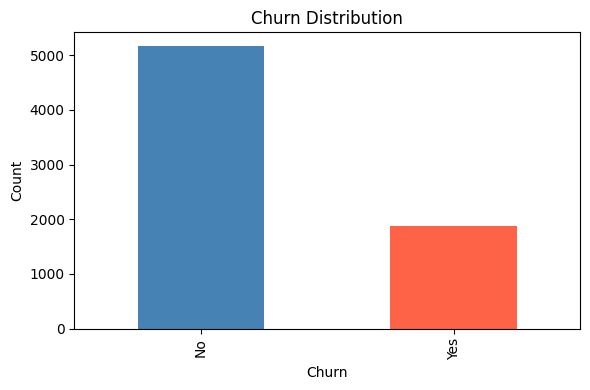

In [8]:
# Step 4: EDA - Churn Distribution
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar',
    color=['steelblue','tomato'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_7167/2617639576.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges',


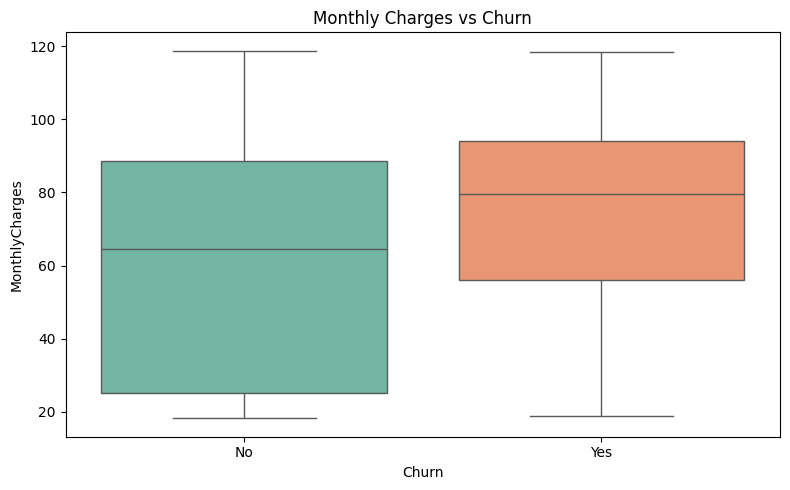

In [9]:
# Step 5: Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges',
    data=df, palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.tight_layout()
plt.show()

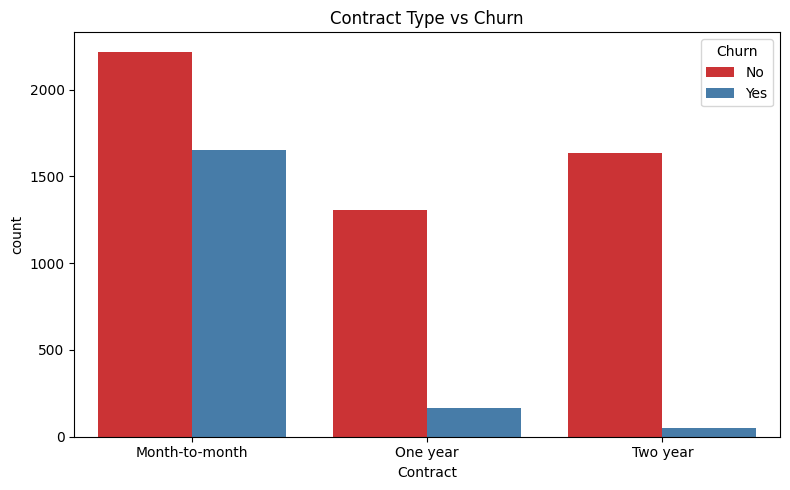

In [10]:
# Step 6: Contract Type vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn',
    data=df, palette='Set1')
plt.title('Contract Type vs Churn')
plt.tight_layout()
plt.show()

In [11]:
# Step 7: Encoding + Model
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Encoding
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Split
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, rf_pred):.2f}")
print(classification_report(y_test, rf_pred))

Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



/tmp/ipykernel_7167/3228763632.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


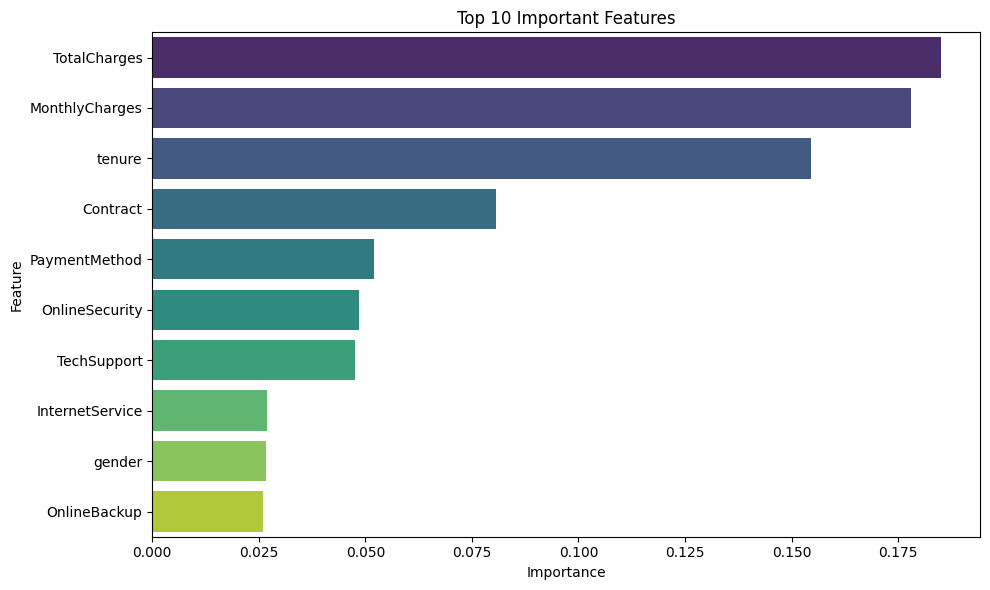

            Feature  Importance
18     TotalCharges    0.184953
17   MonthlyCharges    0.178014
4            tenure    0.154510
14         Contract    0.080585
16    PaymentMethod    0.052031
8    OnlineSecurity    0.048509
11      TechSupport    0.047581
7   InternetService    0.026813
0            gender    0.026715
9      OnlineBackup    0.025883


In [12]:
# Step 8: Feature Importance
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature',
    data=feat_imp.head(10), palette='viridis')
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()

print(feat_imp.head(10))